<a href="https://colab.research.google.com/github/Afaryudha/Deep-Learning2/blob/main/Deep_Learning2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Necessary Libraries

In [7]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models

# Load and Transform Data

In [8]:
data_dir = "/content/drive/MyDrive/Dataset_split"

img_size = (150, 150)
batch_size = 16

# Bagian Train Dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(data_dir, "train"),
    image_size=img_size,
    batch_size=batch_size  # Sekarang menggunakan nilai 16
)

# Bagian Validation Dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(data_dir, "val"),
    image_size=img_size,
    batch_size=batch_size  # Sekarang menggunakan nilai 16
)

# Bagian Test Dataset
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(data_dir, "test"),
    image_size=img_size,
    batch_size=batch_size, # Sekarang menggunakan nilai 16
    shuffle=False
)


Found 5115 files belonging to 4 classes.
Found 1054 files belonging to 4 classes.
Found 1070 files belonging to 4 classes.


# Placing Data into a Dataframe

In [9]:
image_paths = []
labels = []
for root, dirs, files in os.walk(data_dir + "/train"):
    for file in files:
        image_paths.append(os.path.join(root, file))
        labels.append(os.path.basename(root))

df = pd.DataFrame({"image": image_paths, "label": labels})
print(df.head())

                                               image      label
0  /content/drive/MyDrive/Dataset_split/train/pit...  pituitary
1  /content/drive/MyDrive/Dataset_split/train/pit...  pituitary
2  /content/drive/MyDrive/Dataset_split/train/pit...  pituitary
3  /content/drive/MyDrive/Dataset_split/train/pit...  pituitary
4  /content/drive/MyDrive/Dataset_split/train/pit...  pituitary


# Visualizing images from the dataset

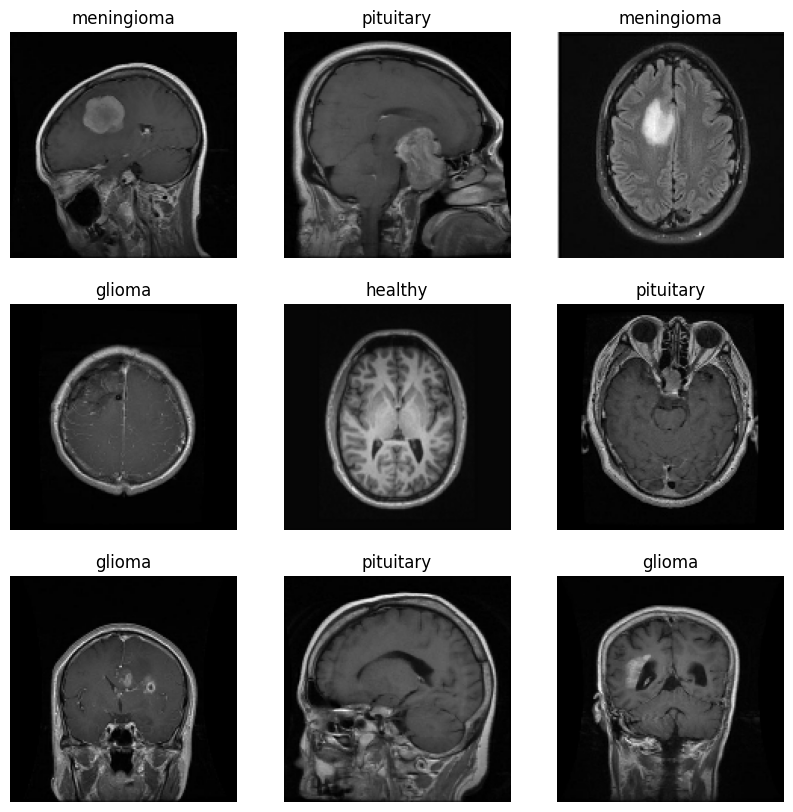

In [10]:
class_names = train_ds.class_names
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")
plt.show()

# Data Preprocessing

In [11]:
normalization_layer = layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

# Training the model

In [13]:
base_model = tf.keras.applications.EfficientNetB0(
    input_shape=(150, 150, 3), # Sesuai img_size baru
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(class_names), activation='softmax')
])

# Tuning Learning Rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Pelatihan Model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)


Epoch 1/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 327s 976ms/step - accuracy: 0.2739 - loss: 1.4783 - val_accuracy: 0.4013 - val_loss: 1.3764
Epoch 2/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 266s 801ms/step - accuracy: 0.3097 - loss: 1.4038 - val_accuracy: 0.3548 - val_loss: 1.3448
Epoch 3/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 260s 796ms/step - accuracy: 0.3318 - loss: 1.3752 - val_accuracy: 0.3643 - val_loss: 1.3156
Epoch 4/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 297s 929ms/step - accuracy: 0.3546 - loss: 1.3444 - val_accuracy: 0.3824 - val_loss: 1.2918
Epoch 5/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 254s 793ms/step - accuracy: 0.3699 - loss: 1.3266 - val_accuracy: 0.3805 - val_loss: 1.2848
Epoch 6/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 253s 792ms/step - accuracy: 0.3677 - loss: 1.3142 - val_accuracy: 0.3729 - val_loss: 1.2789
Epoch 7/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 266s 801ms/step - accuracy: 0.3953 - loss: 1.2956 - val_accuracy: 0.3719 - val_loss: 1.2756
Epoch 8/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 254s 793ms/step - accuracy: 0.3902 -

# Model Evaluation

In [14]:
test_loss, test_acc = model.evaluate(test_ds)

print("Test Loss     :", test_loss)
print("Test Accuracy :", test_acc)

67/67 ━━━━━━━━━━━━━━━━━━━━ 173s 3s/step - accuracy: 0.3794 - loss: 1.2507
Test Loss     : 1.2506572008132935
Test Accuracy : 0.37943926453590393


# Computing Error Rate Analysis

67/67 ━━━━━━━━━━━━━━━━━━━━ 54s 748ms/step
ERROR RATE ANALYSIS
Test Accuracy : 0.3794
Error Rate    : 0.6206 (62.06%)
------------------------------
Classification Report:
              precision    recall  f1-score   support

      glioma       0.28      1.00      0.44       246
     healthy       0.88      0.52      0.65       304
  meningioma       0.30      0.01      0.02       256
   pituitary       0.00      0.00      0.00       264

    accuracy                           0.38      1070
   macro avg       0.37      0.38      0.28      1070
weighted avg       0.39      0.38      0.29      1070



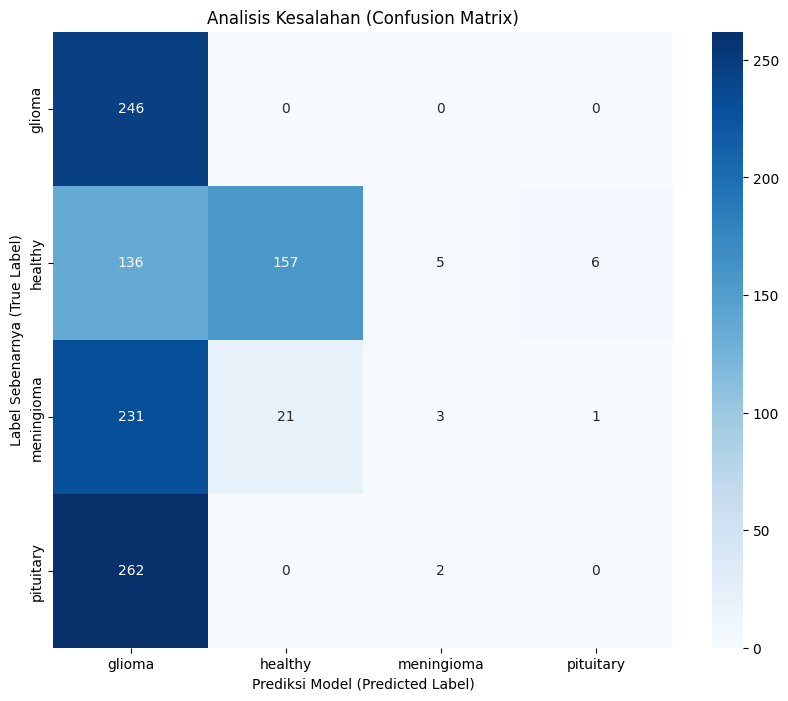

In [21]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# 1. Ambil label asli (y_true) dari test_ds
# Kita kumpulkan semua label dari batch-batch di test_ds
y_true = np.concatenate([y for x, y in test_ds], axis=0)

# 2. Prediksi menggunakan model
# model.predict akan memberikan probabilitas untuk setiap kelas
Y_pred = model.predict(test_ds)
y_pred = np.argmax(Y_pred, axis=1) # Ambil index kelas dengan probabilitas tertinggi

# 3. Hitung Accuracy dan Error Rate
accuracy = np.mean(y_pred == y_true)
error_rate = 1 - accuracy

print("="*30)
print(f"ERROR RATE ANALYSIS")
print("="*30)
print(f"Test Accuracy : {accuracy:.4f}")
print(f"Error Rate    : {error_rate:.4f} ({error_rate*100:.2f}%)")
print("-" * 30)

# 4. Tampilkan Classification Report (Precision, Recall, F1-Score)
# class_names diambil dari dataset yang sudah kamu definisikan sebelumnya
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# 5. Visualisasi Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Analisis Kesalahan (Confusion Matrix)')
plt.ylabel('Label Sebenarnya (True Label)')
plt.xlabel('Prediksi Model (Predicted Label)')
plt.show()


# Visualizing loss curves


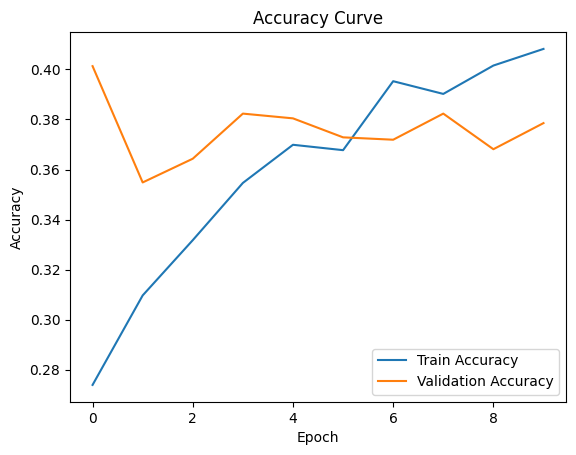

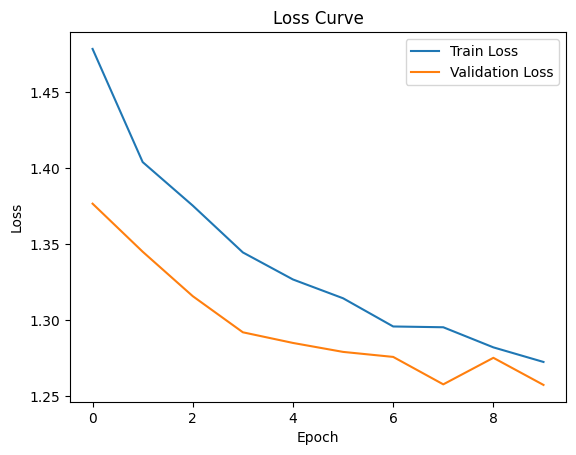

In [22]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# Making predictions on the Test Data

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


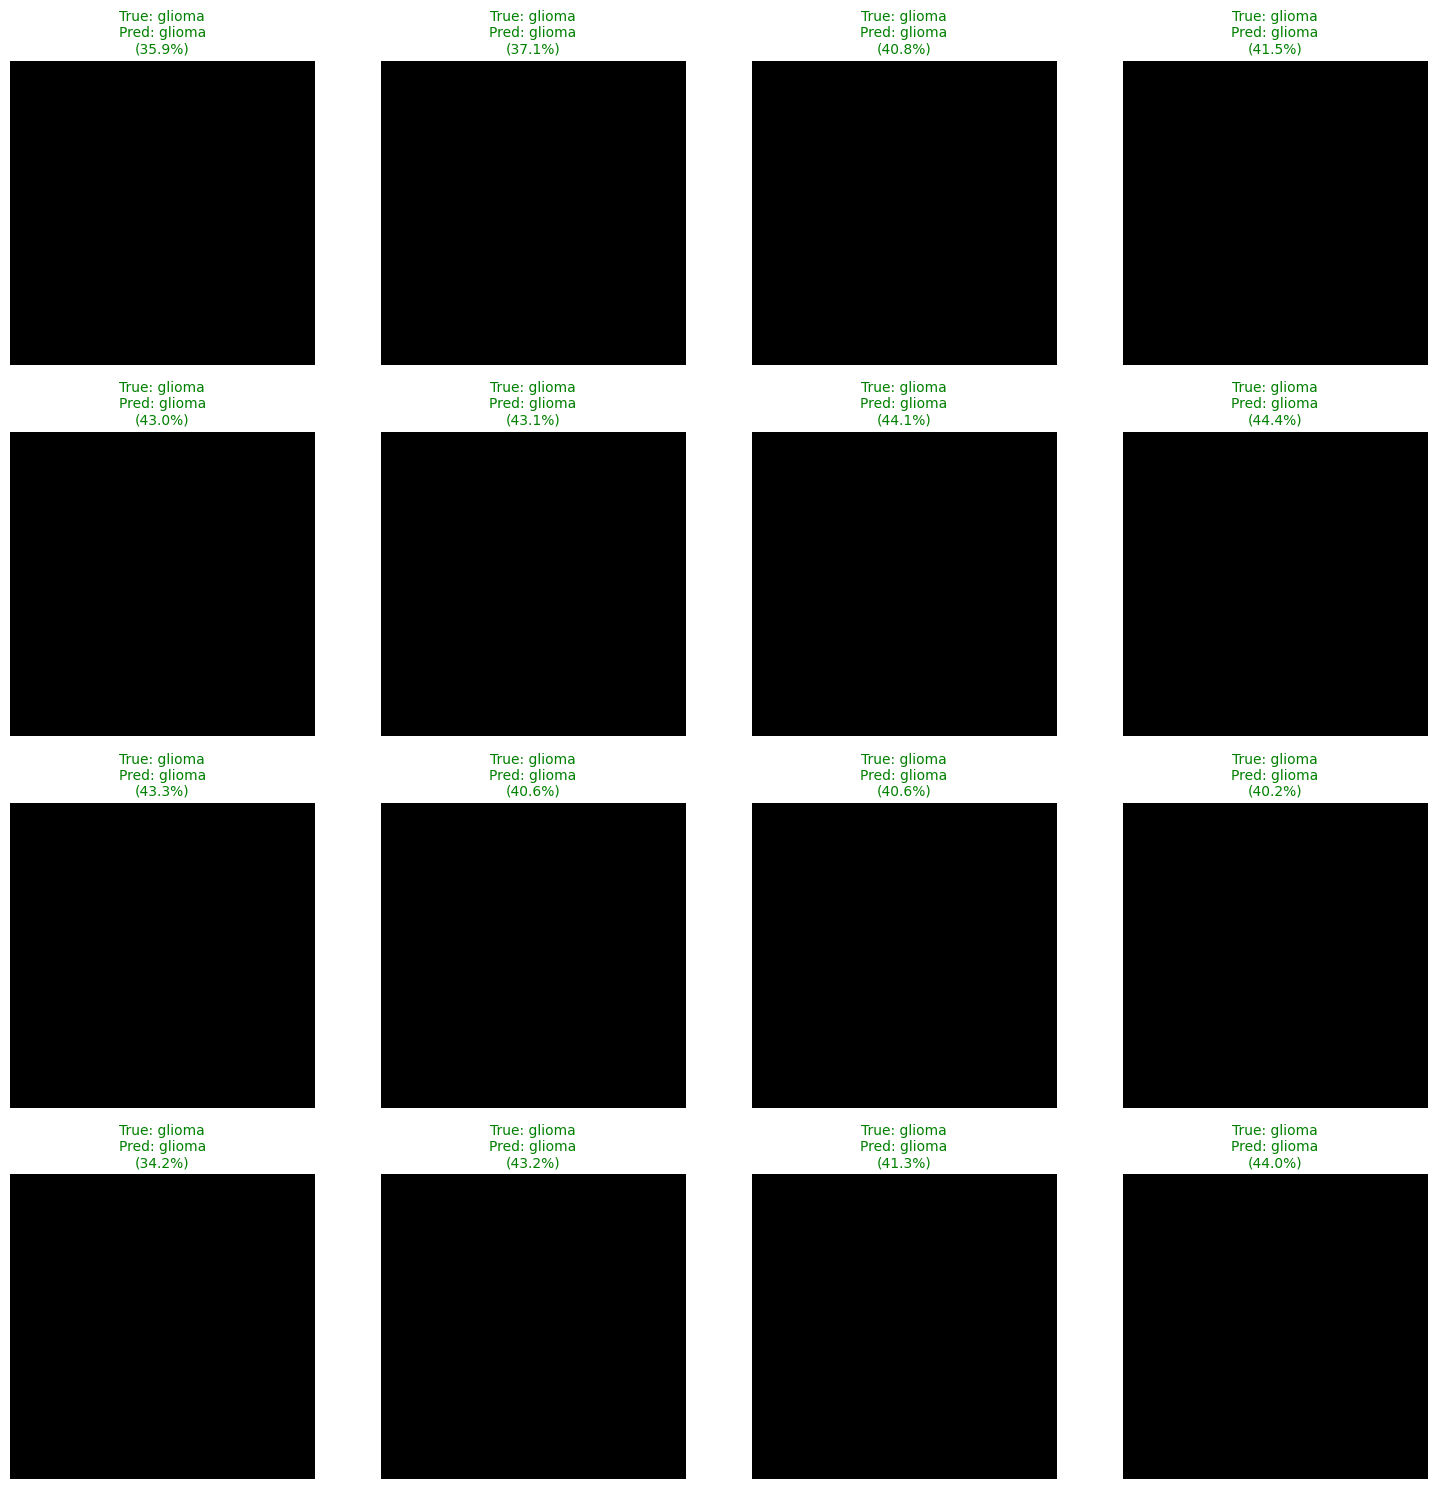

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Ambil satu batch dari test_ds (misal 16 gambar sesuai batch_size kamu)
for images, labels in test_ds.take(1):
    # 2. Lakukan prediksi
    preds = model.predict(images)
    pred_labels = np.argmax(preds, axis=1)

    # 3. Visualisasi Hasil Prediksi
    plt.figure(figsize=(15, 15))
    for i in range(len(images)):
        plt.subplot(4, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))

        # Cek apakah prediksi benar atau salah
        actual = class_names[int(labels[i])]
        predicted = class_names[pred_labels[i]]
        confidence = np.max(preds[i]) * 100

        title_color = "green" if actual == predicted else "red"

        plt.title(f"True: {actual}\nPred: {predicted}\n({confidence:.1f}%)",
                  color=title_color, fontsize=10)
        plt.axis("off")
    plt.tight_layout()
    plt.show()


# Grad-Cam Visualization

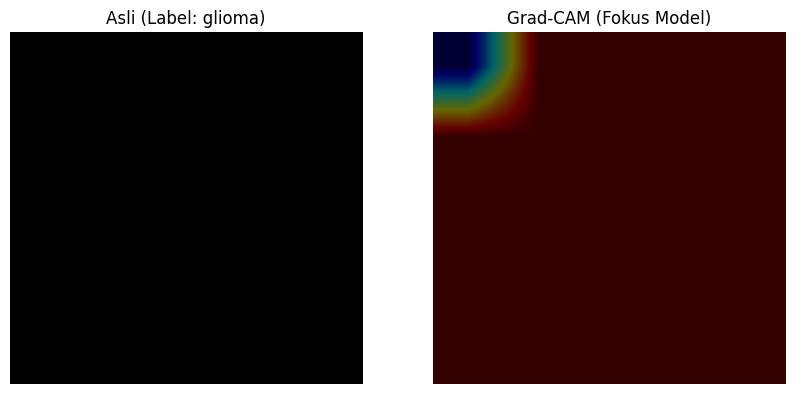

In [29]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

def get_gradcam_heatmap(img_array, model, last_conv_layer_name):
    # Akses base_model dari dalam Sequential
    base_model = model.layers[0]

    # Model fitur
    res_model = tf.keras.Model(base_model.inputs, base_model.get_layer(last_conv_layer_name).output)

    # Model classifier
    classifier_input = tf.keras.Input(shape=base_model.get_layer(last_conv_layer_name).output.shape[1:])
    x = classifier_input
    for layer in model.layers[1:]:
        x = layer(x)
    classifier_model = tf.keras.Model(classifier_input, x)

    with tf.GradientTape() as tape:
        last_conv_layer_output = res_model(img_array)
        tape.watch(last_conv_layer_output)
        preds = classifier_model(last_conv_layer_output)
        # Ambil index prediksi tertinggi sebagai scalar
        top_pred_index = tf.argmax(preds[0])
        top_class_channel = preds[:, top_pred_index]

    grads = tape.gradient(top_class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    heatmap = last_conv_layer_output[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

# TAMPILKAN OUTPUT
last_conv_layer_name = "top_activation"

for images, labels in test_ds.take(1):
    img = images[0] # Ambil 1 gambar saja untuk tes awal
    img_array = tf.expand_dims(img, axis=0)

    # Hitung Heatmap
    heatmap = get_gradcam_heatmap(img_array, model, last_conv_layer_name)

    # Resize & Color
    heatmap = cv2.resize(heatmap, (150, 150))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # Overlay
    original_img = img.numpy().astype("uint8")
    superimposed_img = cv2.addWeighted(original_img, 0.6, heatmap, 0.4, 0)

    # Plot Akhir
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(original_img)
    plt.title(f"Asli (Label: {class_names[labels[0]]})")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(superimposed_img)
    plt.title("Grad-CAM (Fokus Model)")
    plt.axis("off")
    plt.show()
    break
